# Surface-Wave Dispersion Inversion Demo

**Author:** Yusong Yuan, CUG  
**Email:** yuanyusong25@gmail.com  
**Repository:** [`dispinv`](https://github.com/YuanYusung/dispinv.git)  
**Description:** A simple demo for 1D surface-wave dispersion curve inversion using several optimization strategies.

## Overview

This notebook provides a simple demonstration of **1D layered-model inversion** for **surface-wave phase (or group) velocity dispersion curves**.  
It is intended for **initial learning, testing, and method comparison**.

## What this notebook does

In this demo, we:

1. Define a simple synthetic layered velocity model  
2. Compute the corresponding Surface-wave (Rayleigh) dispersion curve  
3. Add a small amount of noise to simulate observed data  
4. Perform inversion using the implemented optimization methods  
5. Compare the inverted model with the reference model  
6. Visualize the dispersion fitting result and the recovered subsurface structure  

---

**Dependencies**

This notebook relies on:

- `numpy`
- `matplotlib`
- `scipy`
- `disba (for dispersion calculation)`
- `emcee` (for MCMC-related workflows)

Please make sure the required packages are installed before running the notebook.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from disba import PhaseDispersion, depthplot
import subfunctions as sf
from Least_squares import invert_dispersion_ls

# Reproducibility for synthetic noise
np.random.seed(42)

In [3]:
# Synthetic dispersion data generation

velocity_model = np.array([
    [20.0, 600.0,  300.0, 2000.0],
    [40.0, 1400.0,  700.0, 2000.0],
    [ 0.0, 2000.0, 1000.0, 2000.0],
]) * 1.0e-3  # convert from (m, m/s, m/s, kg/m^3) to (km, km/s, km/s, g/cc)-like scale

# Thickness array for plotting (use a dummy last layer thickness for depthplot)
thk_true = np.append(velocity_model[:-1, 0].copy(), 1.0)
vs_true  = velocity_model[:, 2].copy()

# Period sampling (s)
# Here we create frequencies 3~10 Hz and convert to periods (reversed)
f = np.linspace(1.0, 10.0, 20)     # Hz
periods = 1.0 / f[::-1]            # s (ascending)

pd = PhaseDispersion(*velocity_model.T)
cpr = pd(periods, mode=0, wave="rayleigh")

syn_period = cpr.period
syn_velocity = cpr.velocity + 0.01 * np.random.randn(len(cpr.velocity))  # add noise

`xtol` termination condition is satisfied.
Function evaluations 21, initial cost 4.6329e-02, final cost 4.3211e-02, first-order optimality 8.08e-01.

=== Inversion result ===
success: True
message: `xtol` termination condition is satisfied.
x0     : [0.01 0.04 0.2  0.6  1.1 ]
x_inv  : [0.01017193 0.0405854  0.19929024 0.59971173 1.09945931]

Inverted model [thk vp vs rho]:
 [[0.01017193 0.39858047 0.19929024 2.        ]
 [0.0405854  1.19942345 0.59971173 2.        ]
 [0.         2.19891862 1.09945931 2.        ]]


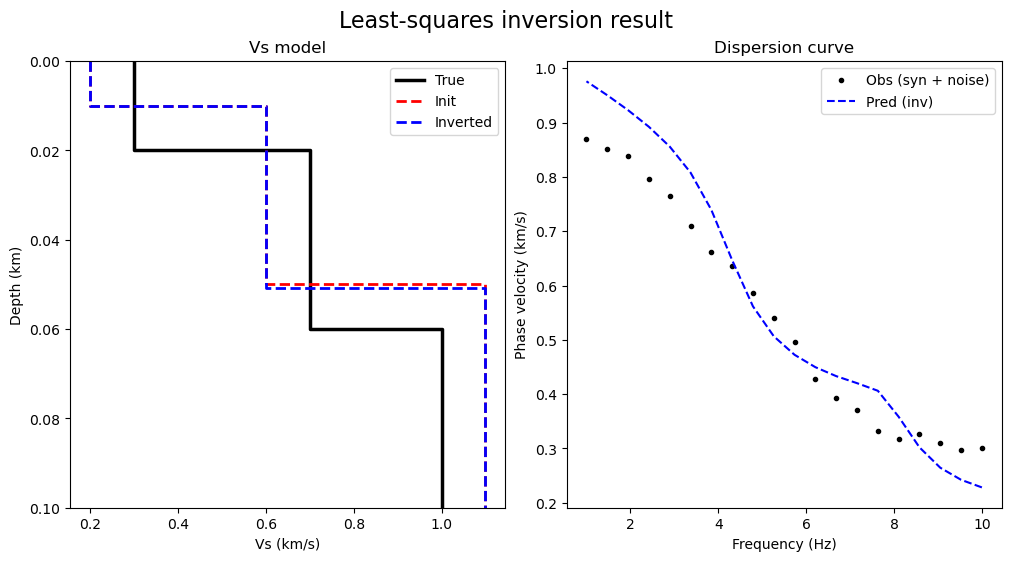

In [3]:
# An example of performing least-squares inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

res, model_inv = invert_dispersion_ls(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
    method="trf",     # change to "lm" if you want (no bounds)
    verbose=1
)

print("\n=== Inversion result ===")
print("success:", res.success)
print("message:", res.message)
print("x0     :", x0)
print("x_inv  :", res.x)
print("\nInverted model [thk vp vs rho]:\n", model_inv)


# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_inv,  vs_inv  = sf.params2_thk_vs(res.x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle("Least-squares inversion result", fontsize=16)
# (1) Vs-depth model comparison
ax0 = axes[0]
depthplot(thk_true, vs_true, ax=ax0, plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0, plot_args={"color": "r", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_inv,  vs_inv,  ax=ax0, plot_args={"color": "b", "linewidth": 2.0, "linestyle": "--"})
ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.legend(["True", "Init", "Inverted"], loc="best")
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")


# (2) Dispersion curve comparison
pred_init = sf.forward_disp(x0,    syn_period, mode=mode)
pred_inv  = sf.forward_disp(res.x, syn_period, mode=mode)

ax1 = axes[1]
ax1.plot(1.0 / syn_period, syn_velocity, "k.", label="Obs (syn + noise)")
#ax1.plot(1.0 / syn_period, pred_init,    "r-", label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_inv,     "b--", label="Pred (inv)")
ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

plt.savefig("ls_inversion_result.png", dpi=150)
plt.show()

Optimization terminated successfully.
         Current function value: 0.000883
         Iterations: 21
         Function evaluations: 27
         Gradient evaluations: 27

=== Inversion result ===
success: True
message: Optimization terminated successfully.
x0     : [0.01 0.04 0.2  0.6  1.1 ]
x_inv  : [0.02069689 0.04594091 0.30674586 0.72128945 0.9926852 ]

Inverted model [thk vp vs rho]:
 [[0.02069689 0.61349172 0.30674586 2.        ]
 [0.04594091 1.44257889 0.72128945 2.        ]
 [0.         1.9853704  0.9926852  2.        ]]


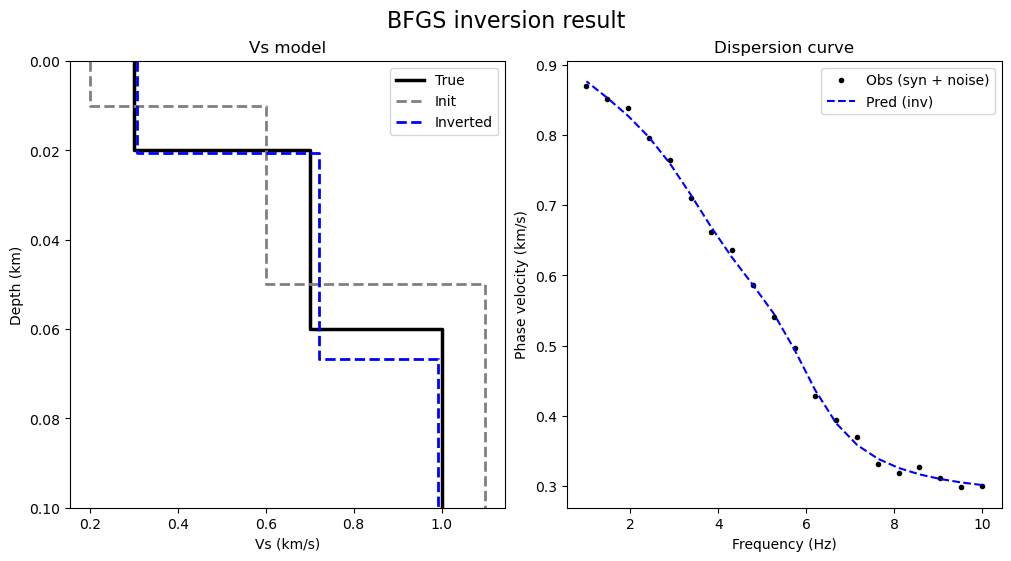

In [ ]:
from BFGS import invert_dispersion_bfgs
# An example of performing BFGS inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01,0.04])     # km the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1]) # km/s 
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

res, model_inv = invert_dispersion_bfgs(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
)

print("\n=== Inversion result ===")
print("success:", res.success)
print("message:", res.message)
print("x0     :", x0)
print("x_inv  :", res.x)
print("\nInverted model [thk vp vs rho]:\n", model_inv)


# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_inv,  vs_inv  = sf.params2_thk_vs(res.x)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), constrained_layout=True)
fig.suptitle("BFGS inversion result", fontsize=16)
# (1) Vs-depth model comparison
ax0 = axes[0]
depthplot(thk_true, vs_true, ax=ax0, plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-"})
depthplot(thk_init, vs_init, ax=ax0, plot_args={"color": "gray", "linewidth": 2.0, "linestyle": "--"})
depthplot(thk_inv,  vs_inv,  ax=ax0, plot_args={"color": "b", "linewidth": 2.0, "linestyle": "--"})
ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.legend(["True", "Init", "Inverted"], loc="best")
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")


# (2) Dispersion curve comparison
pred_init = sf.forward_disp(x0,    syn_period, mode=mode)
pred_inv  = sf.forward_disp(res.x, syn_period, mode=mode)

ax1 = axes[1]
ax1.plot(1.0 / syn_period, syn_velocity, "k.", label="Obs (syn + noise)")
#ax1.plot(1.0 / syn_period, pred_init,    "gray-", label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_inv,     "b--", label="Pred (inv)")
ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

plt.savefig("BFGS_inversion_result.png", dpi=150)
plt.show()

Running MCMC...


100%|██████████| 500/500 [00:04<00:00, 107.50it/s]



=== Inversion result ===
x0       : [0.01 0.04 0.2  0.6  1.1 ]
x_best   : [0.02051514 0.0450469  0.30590205 0.71443974 0.99328384]
lnprob_max: -1.114858466857433


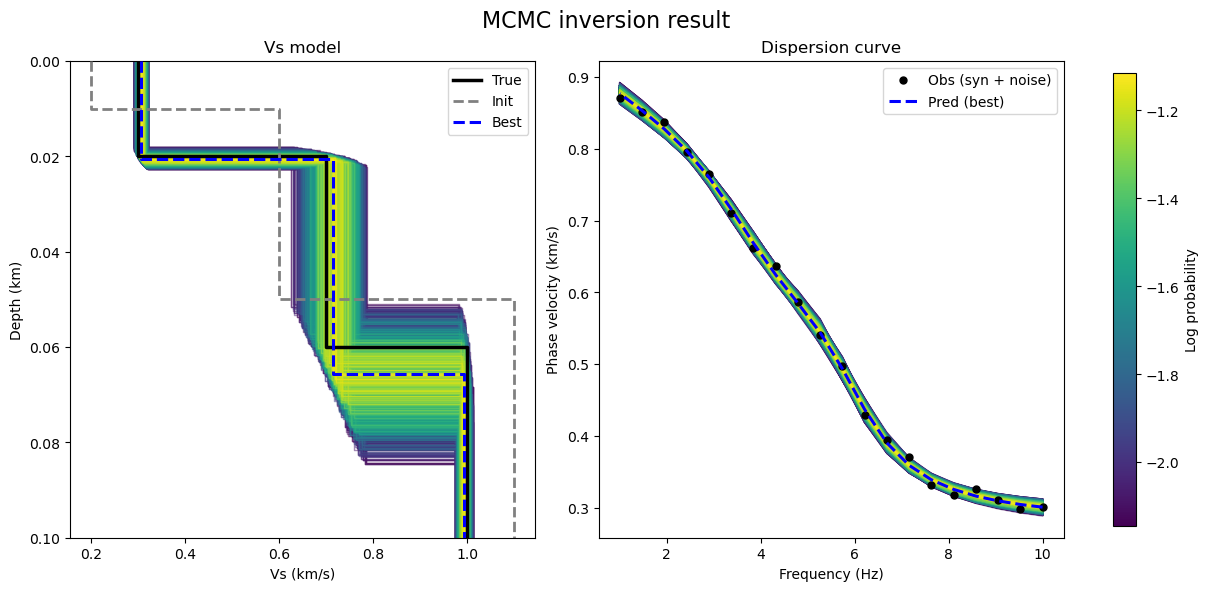

In [36]:
from MCMC_inversion import run_mcmc

# An example of performing MCMC inversion

# Initial guess (example)
# parameters = [thk(n-1), vs(n)]
mode = 0

thk0 = np.array([0.01, 0.04])     # km, the thickness of the half-space is not needed
vs0  = np.array([0.2, 0.6, 1.1])  # km/s
n_layers = len(vs0)

x0 = np.r_[thk0, vs0]

# Run MCMC inversion
sampler = run_mcmc(
    observed_periods=syn_period,
    observed_velocity=syn_velocity,
    mode=mode,
    x0=x0,
    n_layers=n_layers,
    sigma=0.02,
    nwalkers=100,
    nsteps=500
)

# Extract MCMC samples and corresponding log probabilities
samples = sampler.get_chain(flat=True)
ln_probabilities = sampler.get_log_prob(flat=True)

# Best-fit model (maximum log probability)
index = np.argmax(ln_probabilities)
best_model = samples[index]

print("\n=== Inversion result ===")
print("x0       :", x0)
print("x_best   :", best_model)
print("lnprob_max:", np.max(ln_probabilities))

# Convert parameter vectors to thickness/vs for plotting
thk_init, vs_init = sf.params2_thk_vs(x0)
thk_best, vs_best = sf.params2_thk_vs(best_model)

# ----------------------------------
# Select valid samples for plotting
# ----------------------------------
valid = np.isfinite(ln_probabilities)
samples_valid = samples[valid]
lnprob_valid = ln_probabilities[valid]

# Keep the best n_show models for visualization
n_show = min(5000, int(0.1 * len(lnprob_valid)))
sorted_idx = np.argsort(lnprob_valid)[::-1]   # high to low
show_idx = sorted_idx[:n_show]

samples_show = samples_valid[show_idx]
lnprob_show = lnprob_valid[show_idx]

# Sort from low to high so better-fitting models are drawn last
plot_order = np.argsort(lnprob_show)
samples_plot = samples_show[plot_order]
lnprob_plot = lnprob_show[plot_order]

# Colormap based on log probability
lnmin, lnmax = np.min(lnprob_plot), np.max(lnprob_plot)
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=lnmin, vmax=lnmax)

# ----------------------------------
# Visualization
# ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), constrained_layout=True)
fig.suptitle("MCMC inversion result", fontsize=16)

# (1) Vs-depth model comparison
ax0 = axes[0]

# Overlay true / init / best models
depthplot(thk_true, vs_true, ax=ax0,
          plot_args={"color": "k", "linewidth": 2.5, "linestyle": "-", "zorder": 10})
depthplot(thk_init, vs_init, ax=ax0,
          plot_args={"color": "gray", "linewidth": 2.0, "linestyle": "--", "zorder": 10})
depthplot(thk_best, vs_best, ax=ax0,
          plot_args={"color": "b", "linewidth": 2.2, "linestyle": "--", "zorder": 10})

ax0.legend(["True", "Init", "Best"], loc="best")


# Plot sampled models first
for p, lp in zip(samples_plot, lnprob_plot):
    color = cmap(norm(lp))
    thk_i, vs_i = sf.params2_thk_vs(p)
    depthplot(
        thk_i, vs_i, ax=ax0,
        plot_args={"color": color, "linewidth": 1.0, "alpha": 0.5, "zorder": 1}
    )

ax0.set_title("Vs model")
ax0.set_ylim(0.1, 0.0)
ax0.set_xlabel("Vs (km/s)")
ax0.set_ylabel("Depth (km)")

# (2) Dispersion curve comparison
ax1 = axes[1]

# Plot sampled dispersion curves first
for p, lp in zip(samples_plot, lnprob_plot):
    color = cmap(norm(lp))
    try:
        pred_i = sf.forward_disp(p, syn_period, mode=mode)
        if pred_i is not None and np.all(np.isfinite(pred_i)):
            ax1.plot(1.0 / syn_period, pred_i, color=color, linewidth=1.0, alpha=0.5)
    except Exception:
        pass

# Overlay observed / init / best curves
pred_init = sf.forward_disp(x0, syn_period, mode=mode)
pred_best = sf.forward_disp(best_model, syn_period, mode=mode)

ax1.plot(1.0 / syn_period, syn_velocity, "k.", ms=10, label="Obs (syn + noise)")
# ax1.plot(1.0 / syn_period, pred_init, "gray-", linewidth=2.0, label="Pred (init)")
ax1.plot(1.0 / syn_period, pred_best, "b--", linewidth=2.2, label="Pred (best)")

ax1.set_title("Dispersion curve")
ax1.set_xlabel("Frequency (Hz)")
ax1.set_ylabel("Phase velocity (km/s)")
ax1.legend(loc="best")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.95)
cbar.set_label("Log probability")

plt.savefig("MCMC_inversion_result.png", dpi=150)
plt.show()